<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Red-neuronal-artificial-en-PyTorch---MNIST" data-toc-modified-id="Red-neuronal-artificial-en-PyTorch---MNIST-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Red neuronal artificial en PyTorch - MNIST</a></span><ul class="toc-item"><li><span><a href="#Carga-de-datos" data-toc-modified-id="Carga-de-datos-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Carga de datos</a></span></li><li><span><a href="#Preprocesamiento-de-los-datos" data-toc-modified-id="Preprocesamiento-de-los-datos-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Preprocesamiento de los datos</a></span></li></ul></li><li><span><a href="#Construcción-de-ANN-con-PyTorch" data-toc-modified-id="Construcción-de-ANN-con-PyTorch-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Construcción de ANN con PyTorch</a></span><ul class="toc-item"><li><span><a href="#Entrenamiento-del-modelo" data-toc-modified-id="Entrenamiento-del-modelo-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Entrenamiento del modelo</a></span></li><li><span><a href="#Búsqueda-de-mejor-arquitectura-por-optimización-bayesiana" data-toc-modified-id="Búsqueda-de-mejor-arquitectura-por-optimización-bayesiana-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Búsqueda de mejor arquitectura por optimización bayesiana

# Red neuronal artificial en PyTorch - MNIST

Bibliografía:
- Machine Learning with PyTorch and Scikit-Learn: Develop machine learning and deep learning models with Python (capítulos 11, 12, 13), Sebastian Rachska et al., 2022 Packt
- Deep Learning with PyTorch, Eli Stevens et al, 2020 Manning
- Deep Learning with Python (capítulo 2), Francois Chollet, 2018 Manning
- https://pytorch.org/tutorials
- https://www.coursera.org/learn/neural-networks-deep-learning/lecture/6dDj7/backpropagation-intuition-optional, Andrew Ng, 2018 DeepLearning.ai

En este noteboook presentamos:
- Uso de un dataset incluido internamente en Torchvision (MNIST)
- Construcción de modelos de clasificación utilizando capas **Flatten** y **Dense**, con funciones de activación **ReLU**
- Ciclo de entrenamiento de modelos en PyTorch


Utilizamos los siguientes componentes técnicos:
- layers: Flatten, Dense
- optimizadores: Adam
- loss functions: CrossEntropyLoss
- métricas de seguimiento y evaluación: Accuracy
- funciones de activación: relu
- callback de cálculo de métricas


Vamos en este notebook a implementar una red neuronal que permita la clasificación de imágenes de dígitos en escala de grises, utilizando tres niveles de extracción de programación.
Presentamos las librerías **pytorch** a través de su aplicación al problema de clasificación mencionado.
El modelo a implementar es una red con una capa escondida de 512 neuronas utilizando la función de activación **ReLU** y 10 neuronas de salida, con los **logits** resultantes. No vamos a utilizar directamente la función de activación **Softmax** para la capa de salida, los logits serán tratados de manera más eficiente por una función de pérdida que no requiere que las predicciones sean ya una distribución de probabilidad.

Vamos a seguir un protocolo de *holdout* para evaluar los clasificadores durante el proceso de entrenamiento.

In [1]:
import os # gestion de archivos y directorios
import os.path as osp # gestion de paths de archivos y directorios
import time

import numpy as np
import random
import matplotlib.pyplot as plt
import torch, torchvision
import torch.nn.functional as F
from torch import nn

In [3]:
!pip install torchmetrics
import torchmetrics # métricas de modelos

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 57.1 MB/s eta 0:00:00


In [4]:
torch.__version__

'2.10.0+cu128'

Si hay una GPU disponible, la utilizaremos.

In [ ]:
!nvidia-smi

Fri Sep  9 02:23:34 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   35C    P8     9W /  70W |      3MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [5]:
if torch.cuda.is_available():
    print("Utilizamos la primera GPU disponible")
    DEVICE='cuda:0'
else:
    print("No hay GPU, toca correr todo en CPU")
    DEVICE='cpu'

Utilizamos la primera GPU disponible


## Carga de datos

Vamos a descargar el dataset de MNIST y a grabarlo en el directorio ../data.

El paquete **torchvision** incluye varios datasets (instancias de ```torch.utils.data.Dataset```), entre ellos el MNIST, además de incluir transformaciones muy útiles como crear tensores a partir de la data cargada, normalizaciones, recorte de imágenes, etc.
Se debe especificar el lugar físico del disco duro donde quedará el dataset (argumento ```root```), si se trata de dataset de entrenamiento o no (argumento ```train```), si se desea descagar los datos físicamente o no en el directorio especificado por ```root``` (argumento ```download```), las transformaciones a aplicar a la data independiente (argumento ```transform```) o las variables dependientes si se requieren (argumento ```target_transform```).

Las transformaciones más usuales son:
- ```torchvision.transforms.ToTensor()```, convierte **numpy arrays** o imágenes **PIL** a tensores de PyTorch.
- ```torchvision.transforms.Resize()```, modifica las dimensiones de imágenes especificando (alto, ancho), la representación es **channel-first**.
- ```torchvision.transforms.Normalize()```, estandariza los datos dados un promedio y desviación estándar pasados como argumento.
- ```torchvision.transforms.AutoAugment()```, utilizada para data augmentation de imágenes. Recibe una política ```torchvision.transforms.AutoAugmentPolicy()``` aprendida de datasets de imágenes estándares, como CIFAR10, IMAGENET, SVHN.

In [6]:
# Verificamos que exista el directorio de data, sino, lo creamos
if not os.path.exists("../data"):
    os.mkdir("../data")

In [7]:
dataset_train_descargado = torchvision.datasets.MNIST(
    root='/data/', train=True, download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
    ]))

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.14MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 136kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.65MB/s]


In [8]:
dataset_train_descargado

Dataset MNIST
    Number of datapoints: 60000
    Root location: /data/
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
           )

In [9]:
dataset_val_descargado = torchvision.datasets.MNIST(
    root='/data/', train=False, download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
    ]))

In [10]:
dataset_val_descargado

Dataset MNIST
    Number of datapoints: 10000
    Root location: /data/
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
           )

Podemos acceder a los datos del Dataset con sus atributos ```data``` y ```classes```

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
dataset_train_descargado.data.shape

torch.Size([60000, 28, 28])

In [13]:
dataset_train_descargado.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [14]:
dataset_val_descargado.data.shape

torch.Size([10000, 28, 28])

El dataset de entrenamiento consta de 60000 imágenes, y el de validación de 10000 imágenes, de 28 pixeles por 28 pixeles.
Cabe recalcar que no hay canales de color, por lo que se trata de imágenes en escala de grises.

Podemos recorrer las instancias de ```Dataset``` a partir de índices; lo haremos para visualizar algunas de las imágenes, con sus etiquetas correspondientes.

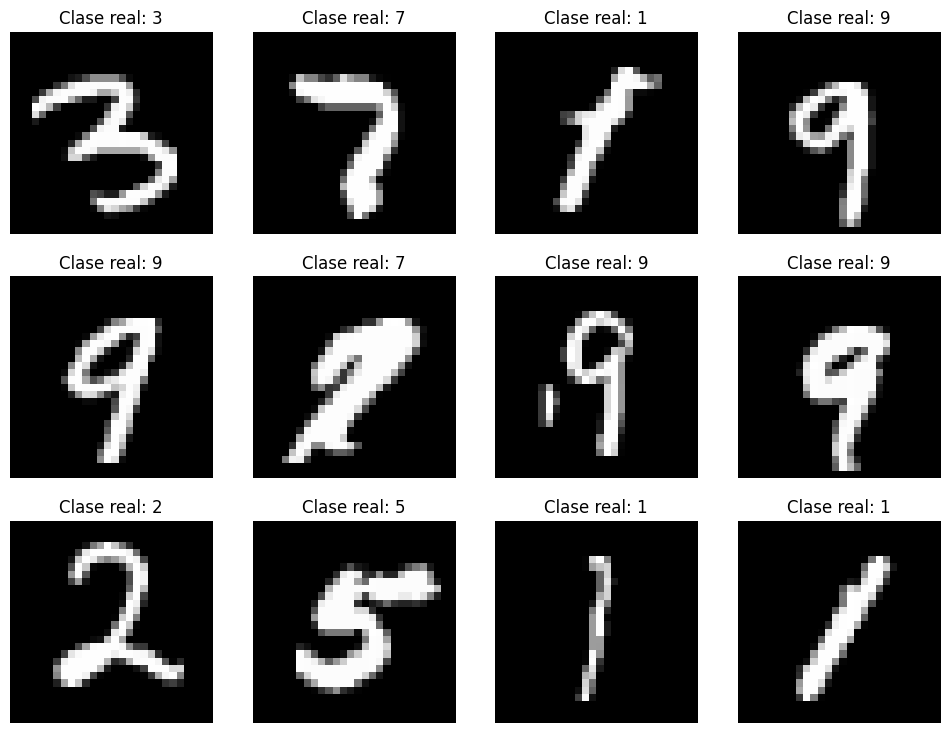

In [15]:
figure = plt.figure(figsize=(12, 9))

cols, rows = 4, 3
for i in range(1, cols * rows + 1):
    # se escoge una imágen aleatoriamente
    sample_idx = torch.randint(len(dataset_train_descargado), size=(1,)).item()
    img, label = dataset_train_descargado[sample_idx]
    # se plotea
    figure.add_subplot(rows, cols, i)
    plt.title(f"Clase real: {label}")
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")

plt.show()

Las instancias de ```torch.utils.data.Dataset``` y pueden ser manipulados por la clase ```torch.utils.data.DataLoader```, un iterador que utilzaremos para poder cargar en memoria el dataset, separado en tensores de variables independientes y variables dependientes, permitiendo establecer además el muestreo que se utilizará al consumir el dataset en términos de tamaños de batch y de aleatoriedad en la composición de los mismos.
Esta clase recibe, entre otros, los siguientes parámetros:
- ```dataset```: la instancia de ```Dataset``` a tratar
- ```batch_size```: el tamaño del batch a considerar cuando se pide un paquete de datos
- ```shuffle```: si se requiere o no organizar los datos aleatoriamente antes de crear los batches
- ```num_workers```: para optimizar el tiempo de procesamiento paralelizando la carga de datos en varios cores de procesamiento.

In [16]:
batch_size_train = 512
batch_size_val = 1024
train_loader = torch.utils.data.DataLoader(dataset_train_descargado, batch_size=batch_size_train, shuffle=True, num_workers=2)
val_loader = torch.utils.data.DataLoader(dataset_val_descargado, batch_size=batch_size_val, shuffle=False, num_workers=2)

Se puede iterar sobre el dataloader para acceder a cada batch de imágenes y etiquetas.
Obtengamos una imagen y analicemos los datos retornados por el data loader.

In [21]:
train_features, train_labels = next(iter(train_loader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0]
label = train_labels[0]

Feature batch shape: torch.Size([512, 1, 28, 28])
Labels batch shape: torch.Size([512])


Los tensores retornados por el ```DataLoader``` de entrenamiento para las variables independientes están organizados de esta manera:
- el primer rango corresponde al tamaño del batch size
- el segundo rango tiene un valor de 1, correspondiente al canal de color (gris)
- los dos rangos siguientes tienen las dimensiones correspondientes al alto y ancho de las imágenes (28x28). Cada valor de la matriz de 28x28 es una valor de gris de 0 a 1.

El tensor correspondiente a los labels solo consta de un rango, que da el tamaño del vector de clases de cada instancia de del batch.

Veamos la imágen y algunas de las filas de la imagen correspondiente.

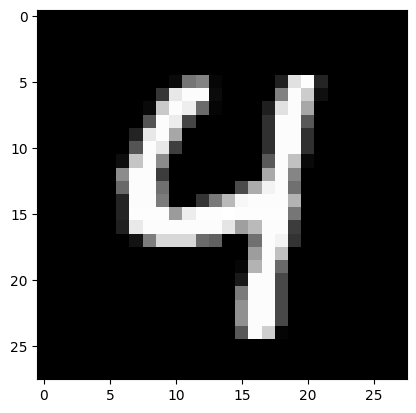

Label: 4


In [23]:
plt.imshow(img.squeeze(), cmap="gray") # como es escala de grises quitamos el eje del canal
plt.show()
print(f"Label: {label}")

In [24]:
img[0][5:8]

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0392, 0.4588, 0.5176, 0.0235, 0.0000, 0.0000, 0.0000, 0.0000,
         0.1255, 0.8824, 0.9922, 0.1412, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.2118, 0.9098, 0.9882, 0.9882, 0.0431, 0.0000, 0.0000, 0.0000, 0.0000,
         0.5059, 0.9882, 0.8000, 0.0588, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0353,
         0.7882, 0.9882, 0.9333, 0.4196, 0.0196, 0.0000, 0.0000, 0.0000, 0.1216,
         0.8824, 0.9882, 0.6549, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000]])

Los datos ya están normalizados de tal manera que el negro corresponde a un valor de 0 y el blanco a un valor de 1.

## Preprocesamiento de los datos

Necesitamos que los datos de entrenamiento y validación estén en el formato dado por la capa de entrada de la red, donde se reciben los datos representados a partir de un tensor cuya primera dimensión tiene 784 neuronas, es decir, recibe como input instancias representadas por tensores con dimensionalidad (784,).

Cómo los datos de entrenamiento están en tensores de 512x1x28x28, es necesario convertirlos en un tensor de 512x784. Idem para el tensor de validación.

Veamos como quedaría un batch modificado.

In [25]:
train_features.shape

torch.Size([512, 1, 28, 28])

In [26]:
train_features.reshape(batch_size_train, 784).shape

torch.Size([512, 784])

Definimos la estructura de la red (número de neuronas por capa y número de inputs).

In [27]:
n0 = 28*28
n1 = 512
n2 = 10

Los labels son numéricos.

In [28]:
train_labels[:50]

tensor([4, 0, 4, 6, 9, 1, 6, 6, 8, 9, 6, 5, 5, 0, 4, 7, 1, 1, 7, 7, 5, 9, 9, 0,
        3, 0, 6, 1, 1, 2, 8, 2, 3, 5, 4, 8, 0, 9, 0, 3, 5, 5, 6, 6, 1, 5, 1, 8,
        9, 1])

La última capa de la red neuronal tiene 10 neuronas, una por cada dígito (las 10 clases).

# Construcción de ANN con PyTorch

Definimos un modelo sencillo de una capa escondida, con las siguientes características
- la capa de entrada esta va a tener 28x28 = 784 nodos de entrada, 1 por cada pixel de las imágenes. El número de imágenes no se tiene que específicar.
- una capa escondida de 512 neuronas, que utiliza una función de activación **RELU**
- una capa de salida de 10 neuronas, una para cada clase, que retorna los logits predichos.

Del framework de PyTorch, vamos a utilizar los siguientes componentes:
- inicializamos la semilla aleatoria con ```torch.manual_seed()```. En el caso de uso de GPUs con CUDA, se pasa por una librería llamada **cuDNN** que utiliza algoritmos no determinísticos, que se pueden deshabilitar con ```torch.backends.cudnn.enabled = False```.
- capas lineales ```torch.nn.Linear``` que se ocupan de calcular las combinaciones lineales (los "net inputs", las "Zs")
- capas flatten ```torch.nn.Flatten``` que permiten aplanar las dimensiones de tensores de imágenes (de 28x28 pixeles a 784 datos)
- funciones de activación del api funcional ```torch.nn.functional```

Las GPUs y CPUs tienen diferentes semillas de generación aleatoria que no están sincronizadas. Además, algunas operaciones en GPUs se implementan por defecto estocásticamente para que sean más eficientes.
Por todo esto, para garantizar reproducibilidad, necesitamos configurar las semillas por aparte, e indicar el deseo de un proceso determinístico en caso de usar GPUs.

In [29]:
def reset_seed():
    random_seed = 42
    torch.backends.cudnn.enabled = False
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)
    random.seed(random_seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.enabled = True
        torch.cuda.manual_seed(42)
        torch.cuda.manual_seed_all(42)

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

reset_seed()

Analicemos el efecto de una capa ```nn.Flatten``` sobre un batch de imágenes

In [30]:
train_features.shape

torch.Size([512, 1, 28, 28])

In [31]:
flatten = nn.Flatten()
flatten_features = flatten(train_features)
print(flatten_features.shape)

torch.Size([512, 784])


Independientemente de lo que signifiquen, ```Flatten``` siempre va a conservar el primer eje, aplanando todos los demás en un solo eje.
En este caso, podemos ver que los ejes de canales, alto y ancho fueron aplanados, con los 784 píxeles del único pixel fueron reorganizados en un solo eje final, conservando el primer eje del batch.

Creemos la capa escondida inicial, y entendámosla.
Podemos confirmar que sus parámetros tienen las dimensiones esperadas: una matriz de pesos de n1 filas (neuronas) y n0 columnas (pixeles de entrada) y un vector de n1 elementos (un sesgo por neurona).

In [32]:
hidden_layer = nn.Linear(in_features=n0, out_features=n1)

In [33]:
print(f"pesos: {hidden_layer.weight.shape}")
print(f"sesgos: {hidden_layer.bias.shape}")

pesos: torch.Size([512, 784])
sesgos: torch.Size([512])


Veamos la inicialización de los parámetros de las primeras neuronas de la capa escondida:

In [34]:
hidden_layer.weight[0:3]

tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
        [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
        [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059]],
       grad_fn=<SliceBackward0>)

In [35]:
hidden_layer.bias[0:3]

tensor([-0.0155, -0.0327, -0.0134], grad_fn=<SliceBackward0>)

Ahora, procesemos una imagen a través de la capa densa, y veamos el efecto de una función de activación relu.

In [36]:
img = train_features[9]
label = train_labels[9]

In [37]:
image = img.reshape(1, n0)
print("image: ", image.shape, "\n", img[0, 10:14])

z = hidden_layer(image)
print("z: ", z.shape, "\n", z[0, 0:10])

a = nn.ReLU()(z)
print("a: ", a.shape, "\n", a[0, 0:10])


image:  torch.Size([1, 784]) 
 tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1059, 0.9255, 0.9922, 0.6510,
         0.1412, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0941, 0.5176, 0.9922,
         0.9922, 0.4588, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1451, 0.9922, 0.9922, 0.3059,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0118, 0.7333,
         0.9922, 0.7294, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1451, 0.9922, 0.9922, 0.3059,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0863, 0.9098,
         0.9922, 0.7294, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0196, 0.5725, 0.9922, 0.5098,
         0.0353, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1255, 0.9922,
         0.9922, 0.3725,

Vamos a crear una clase de Python que represente el modelo ANN con las dos capas escondidas. Esta clase heredará de ```torch.nn.Module```, para que internamente y automáticamente pueda realizar las operaciones de propagación de gradiente. Esta clase requiere necesariamente al menos de dos métodos:
- un método constructor ```__init__()```, en donde se declaran las capas y demás módulos con parámetros. Este método recibe opcionalmente el número de neuronas a asociar a la capa escondida (por defecto es igual a n1).
- un método ```forward()```, que se encarga de establecer las operaciones del feed forward, que es trackeado indirectamente por PyTorch para la propagación de gradientes.

Adicionalmente, vamos a crear un tercer método privado para inicializar los pesos de manera aleatoria. Utilizamos la inicialización siguiendo una distribución de **Xavier**; se ha demostrado empíricamente que esta inicialización balancea la varianza de los gradientes a través de un conjunto de capas, teniendo en cuenta el número de neuronas de entrada y salida de cada capa. Existen versiones uniforme y normal que siguen esta distribución.

Las funciones de activación, que no disponen de parámetros entrenables, se pueden crear como componentes instanciados de clases dentro del paquete ```torch.nn```, como por ejemplo ```torch.nn.ReLU```, o se pueden implementar llamando a funciones incluidas en el API funcional, e.g. ```torch.nn.functional.relu()```.
Las dos opciones son válidas. En este caso, solo vamos a crear instancias de componentes que tengan parámetros, por lo que usaremos el API funcional para las funciones de activación ReLU.

In [38]:
class MNISTClassifSimpleANN(nn.Module):
    def __init__(self, fc1_n=n1):
        super(MNISTClassifSimpleANN, self).__init__()
        self.flat = nn.Flatten()
        self.fc1 = nn.Linear(in_features=n0, out_features=fc1_n)
        self.fc2 = nn.Linear(in_features=fc1_n, out_features=n2)
        self._reset_params()

    def forward(self, image):
        x = self.flat(image)
        x = self.fc1(x)
        x = F.relu(x)
        logits = self.fc2(x)
        return logits

    def _reset_params(self):
        torch.nn.init.xavier_uniform_(self.fc1.weight)
        torch.nn.init.xavier_uniform_(self.fc2.weight)

Instanciemos la clase del modelo que acabamos de crear y veamos que su estructura solo incluye los componentes que fueron instanciados en el método ```__init__```, aunque sabemos que el método forward estamos encadenando el flujo con las funciones de activación.
Con el método ```named_parameters()``` obtenemos los parámetros entrenables del modelo, que en este caso consisten de:
- pesos de la primera capa densa
- sesgos de la primera capa densa
- pesos de la segunda capa densa
- sesgos de la segunda capa densa

In [39]:
reset_seed()
modelo = MNISTClassifSimpleANN()
print(modelo)

for name, param in modelo.named_parameters():
    print(f"Param: {name} | Size: {param.size()} | Values : {param[:2]} \n")

MNISTClassifSimpleANN(
  (flat): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)
Param: fc1.weight | Size: torch.Size([512, 784]) | Values : tensor([[ 0.0385, -0.0141,  0.0247,  ...,  0.0113,  0.0123,  0.0281],
        [-0.0346, -0.0257, -0.0414,  ...,  0.0045, -0.0229, -0.0258]],
       grad_fn=<SliceBackward0>) 

Param: fc1.bias | Size: torch.Size([512]) | Values : tensor([-0.0155, -0.0327], grad_fn=<SliceBackward0>) 

Param: fc2.weight | Size: torch.Size([10, 512]) | Values : tensor([[-0.0200, -0.0735,  0.0863,  ...,  0.0890, -0.0350,  0.0797],
        [-0.0968, -0.1028,  0.0949,  ...,  0.0496, -0.0981,  0.0685]],
       grad_fn=<SliceBackward0>) 

Param: fc2.bias | Size: torch.Size([10]) | Values : tensor([0.0155, 0.0405], grad_fn=<SliceBackward0>) 



Ahora, apliquemos el modelo recién creado a una de las imágenes.
Recordemos que la red no se ha entrenado, sin embargo ya podemos obtener una predicción.
El modelo espera un batch de imágenes, por lo que siempre es necesario que el tensor que se envíe al modelo incluya el eje inicial del batch.

In [40]:
img.shape

torch.Size([1, 28, 28])

In [41]:
preds = modelo(image)
preds

tensor([[ 0.1036,  0.2102, -0.3326,  0.0772,  0.1253, -0.2868,  0.3451, -0.2117,
          0.2235, -0.1767]], grad_fn=<AddmmBackward0>)

Vemos que las predicciones no constituyen probabilidades, pues pueden haber valores negativos, y su suma no es igual a 1.

Si quisiéramos convertir los logits a probabilidades, usando ```functional.softmax```, indicando el eje de la distribución de probabilidad (1, cada fila del tensor de salida debe sumar 100%) tendríamos:

In [42]:
print(F.softmax(preds, dim=1))

tensor([[0.1073, 0.1194, 0.0694, 0.1045, 0.1097, 0.0726, 0.1367, 0.0783, 0.1210,
         0.0811]], grad_fn=<SoftmaxBackward0>)


Vemos que cada clase tiene una probabilidad cercana al 10%, sin ninguna clase siendo mucho mayor a las demás, pues el modelo está en su estado inicial, con los parámetros incializados manera aleatoria.

## Entrenamiento del modelo

Durante el entrenamiento del modelo necesitamos comparar para todo un batch las predicciones con los valores reales para lo cuál se utiliza una función de pérdida.
En este caso instanciaremos ```nn.CrossEntropyLoss()```.

En PyTorch la función de pérdida de cross-entropy (clase ```torch.nn.CrossEntropyLoss```) no requiere la conversión de las etiquetas de clase de groud truth a vectores **one hot**, ni que las predicciones sean una distribución de probabilidad; trabaja directamente con los logits de las predicciones del modelo y con las etiquetas númericas cómo índice del vector a considerar.
Se vale de optimizaciones del cómputo de la función de pérdida, además es mas estable numéricamente, siendo completamente equivalente a hacer la comparación con el vector one hot con probabilidades, ya que solo considera la neurona con la clase correcta en el cálculo, ignorando todas las demás.

Otra posible opción sería convertir las salidas de la capa final del modelo a probabilidades con ```F.softmax()```, y utilizar la función de pérdida ```nn.NLLLoss``` (Negative Log Likelihood), que sería equivalente a lo anterior, pero tendría menos estabilidad numérica.

Por otra parte, PyTorch se encarga de tener todos los valores intermediarios listos para realizar la propagación del gradiente, sin embargo esta solo se hará una vez se llame al método ```backward()``` del tensor resultante del cálculo de la pérdida.

In [43]:
train_features.shape

torch.Size([512, 1, 28, 28])

In [44]:
loss_fn = nn.CrossEntropyLoss()
preds = modelo(train_features)
loss = loss_fn(preds, train_labels)
loss.backward()
print(loss.item())

2.3743128776550293


Utilizaremos un optimizador **Adam**, instanciando la clase ```torch.optim.Adam```. Al crearlo, le indicaremos los objetivos de optimización (los parámetros del modelo, que se obtienen a partir del método ```parameters()```), así como el learning rate. Se puede especificar otros hiper parámetros más detallados si se desea.

Creamos un ciclo de entrenamiento, con iteraciones sobre la totalidad del dataset (épocas), e iteraciones internas correspondientes a los batches de entrenamiento. Para cada batch se debe:
- Generar las predicciones del batch de features con el modelo
- Comparar con las realidades a partir del loss function (no hay necesidad de una transformación one hot de las etiquetas)
- Calcular los gradientes de la función de pérdida llamando ```backward()``` sobre el tensor del resultado de la pérdida calculada
- Actualizar parámetros con los gradientes llamando al método ```step()``` del optimizador teniendo en cuenta los gradientes previamente calculados.
- Resetear los gradientes para no reacumularlos con los de los siguientes batches, llamando al método ```zero_grad()``` del optimizador después de la actualización de los parámetros a entrenar.
- Para estimar el número de predicciones correctas se utiliza el método ```argmax()``` sobre el tensor de predicciones. Este tensor es de rango 2, se le debe indicar que la dimensión de aplicación de la función de agregación, como el rango 0 es el del batch, se especifica el rango 1.
- Tanto los inputs del modelo como los parámetros del modelo se deben situar en el mismo device. Es por esto que a los features y labels de los batches, como al modelo (a sus parámetros) se les debe llamar el método ```.to(device)```

In [45]:
def train_model(train_batch_size=128, fc1_n=512, learning_rate = 1e-3, epocas=30, device="cpu", verbose=False):
    """Se encarga de realizar el ciclo de épocas de entrenamiento

    :train_batch_size:
        tamaño del batch size de entrenamiento
    :fc1_n:
        número de neuronas de la capa escondida
    :learning_rate:
        learning rate del optimizador.
    :epocas:
        número de iteraciones de entrenamiento sobre el dataset completo
    :device:
        indica el dispositivo de procesamiento (cpu o cuda) sobre el cual se
        va a realizar el entrenamiento
    :verbose:
        indica si se quiere imprimri el avance del proceso o no
    :returns:
        el modelo entrenado y 4 arrays con los valores de losses y accuracies
        del training dataset, los losses y accuracies del val set después de
        cada época, y el tiempo que tomó el proceso en segundos
    """
    start_time = time.time()
    reset_seed()

    # Data loader con el batch size de entrenamiento modificado
    train_loader = torch.utils.data.DataLoader(dataset_train_descargado,
                                               batch_size=train_batch_size,
                                               shuffle=True, num_workers=2)

    # Se crea el modelo y optimizador
    modelo = MNISTClassifSimpleANN(fc1_n=fc1_n)
    modelo = modelo.to(device) # situar el modelo en el dispositivo de procesamiento
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(modelo.parameters(), lr=learning_rate)

    # Creamos vectores donde almacenaremos los losses y métricas despuúes de cada época
    train_losses = [0] * epocas
    train_accuracies = [0] * epocas
    val_losses = [0] * epocas
    val_accuracies = [0] * epocas

    for epoca in range(epocas):
        epoca_start_time = time.time()
        for batch_features, batch_labels in train_loader:
            # Nos aseguramos que los inputs del modelo estén en el mismo dispositivo
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)
            # Generar las predicciones
            batch_preds = modelo(batch_features)
            # Comparar con las realidades a partir del loss function
            loss = loss_fn(batch_preds, batch_labels)
            # Calcular los gradientes de la función de pérdida
            loss.backward()
            # Actualizar parámetros con los gradientes
            optimizer.step()
            # Resetear los gradientes para no reacumularlos
            optimizer.zero_grad()
            # se acumulan los losses de la epoca (ponderados por el tamaño del batch)
            train_losses[epoca] += loss.item() * batch_labels.size(0)
            # se acumulan las predicciones correctas de la epoca
            correctos = (batch_preds.argmax(1) == batch_labels)
            train_accuracies[epoca] += correctos.type(torch.float).sum().item()

        # se normalizan el loss y el accuracy del training set
        train_losses[epoca] /= len(train_loader.dataset)
        train_accuracies[epoca] /= len(train_loader.dataset)

        # se desactiva la diferenciación automática para la inferencia sobre el val set
        with torch.no_grad():
            for batch_features, batch_labels in val_loader:
                # Nos aseguramos que los inputs del modelo estén en el mismo dispositivo
                batch_features = batch_features.to(DEVICE)
                batch_labels = batch_labels.to(DEVICE)
                # Generar las predicciones
                batch_preds = modelo(batch_features)
                # Comparar con las realidades a partir del loss function
                loss = loss_fn(batch_preds, batch_labels)
                # se acumulan los losses de la epoca (ponderados por el tamaño del batch)
                val_losses[epoca] += loss.item() * batch_labels.size(0)
                # se acumulan las predicciones correctas de la epoca
                correctos = (batch_preds.argmax(1) == batch_labels)
                val_accuracies[epoca] += correctos.type(torch.float).sum().item()

        # se normalizan el loss y el accuracy del val set
        val_losses[epoca] /= len(val_loader.dataset)
        val_accuracies[epoca] /= len(val_loader.dataset)

        epoca_end_time = time.time()
        segundos = epoca_end_time - epoca_start_time

        if verbose:
            print(f"{epoca}:  loss: {train_losses[epoca]:>7f}, accuracy: {train_accuracies[epoca]:>7f}, val loss: {val_losses[epoca]:>7f}, val accuracy: {val_accuracies[epoca]:>7f}",
                  f"-- epoch time: {segundos:.2f}")

    end_time = time.time()
    return modelo, train_losses, train_accuracies, val_losses, val_accuracies, (end_time-start_time)

Veamos el tiempo que se toma en entrenar el modelo durante 30 épocas. Si hay una GPU disponible, comparemos el tiempo de entrenamiento del modelo

In [46]:
modelo, train_losses, train_accuracies, val_losses, val_accuracies, tiempo = train_model(
    train_batch_size=1024, fc1_n=512, learning_rate=1e-3, epocas=30, device=DEVICE, verbose=True)
print(f"Tiempo de entrenamiento {tiempo:.2f} segundos")

0:  loss: 0.554273, accuracy: 0.848600, val loss: 0.259230, val accuracy: 0.926200 -- epoch time: 6.79
1:  loss: 0.229984, accuracy: 0.935450, val loss: 0.191548, val accuracy: 0.945900 -- epoch time: 7.77
2:  loss: 0.174511, accuracy: 0.950700, val loss: 0.156578, val accuracy: 0.955000 -- epoch time: 6.42
3:  loss: 0.138648, accuracy: 0.961267, val loss: 0.129117, val accuracy: 0.962800 -- epoch time: 7.77
4:  loss: 0.113558, accuracy: 0.968367, val loss: 0.113182, val accuracy: 0.966400 -- epoch time: 6.41
5:  loss: 0.095834, accuracy: 0.973533, val loss: 0.101358, val accuracy: 0.970800 -- epoch time: 7.86
6:  loss: 0.081254, accuracy: 0.977733, val loss: 0.094246, val accuracy: 0.971800 -- epoch time: 6.36
7:  loss: 0.070503, accuracy: 0.980517, val loss: 0.085907, val accuracy: 0.974400 -- epoch time: 7.82
8:  loss: 0.060315, accuracy: 0.984117, val loss: 0.079454, val accuracy: 0.974900 -- epoch time: 6.46
9:  loss: 0.052942, accuracy: 0.985817, val loss: 0.077630, val accuracy:

El optimizador actualizó los parametros 60000 / 1024 = 59 veces durante cada época, es decir 118 \* 30 = 1770 veces durante todo el entrenamiento, para alcanzar un accuracy de alrededor de 98% después de 30 épocas.

Es importante recalcar que así el accuracy llegue al 100%, el loss puede seguir optimizándose, pues puede que el score de probabilidad de la buena clase no sea aún igual a 1.

Podemos comparar los accuracy del training set y del validation set.

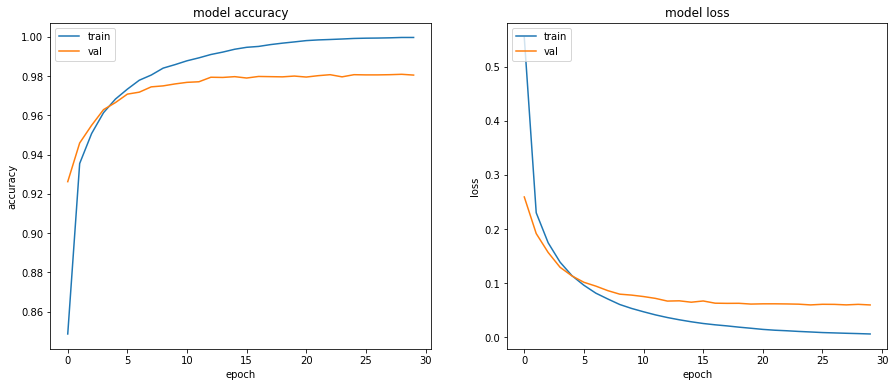

In [ ]:
fig = plt.figure(figsize=(15,6))

ax = fig.add_subplot(1, 2, 1)
ax.plot(train_accuracies)
ax.plot(val_accuracies)
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

ax = fig.add_subplot(1, 2, 2)
ax.plot(train_losses)
ax.plot(val_losses)
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

_=plt.show()


## Búsqueda de mejor arquitectura por optimización bayesiana

La **optimización bayesiana** es una técnica de búsqueda de hiperparámetros de manera más inteligente al clásico **grid search**.
Vamos a aplicarla para establecer los valores mas adecuados para tres hiperparámetros, considerando una arquitectura de red neuronal tradicional de una solo capa escondida:
- el número de neuronas de la capa escondida
- el learning rate
- el batch size del training set

Lo primero que tenemos que hacer es definir la función de caja negra que queremos **maximizar** (ojo, si vamos a optimizar un problema de regresión, tenemos que maximizar "menos el MSE", por ejemplo), utilizando los hiper parámetros recibidos en los argumentos.

En este caso, por simplicidad e interpretabilidad nos interesa maximizar el accuracy del modelo sobre el validation set (aunque podríamos maximizar el valor -loss que sería mas indicado), y queremos hacer variar el número de neuronas de la única capa escondida, el learning rate y el batch_size. Podríamos haber escogido mas hiper parámetros, pero nos limitamos a estos para ser mas ilustrativos.

Vamos solo a correr 5 épocas por cada modelo, para que podamos avanzar rápidamente en la búsqueda de las mejores configuraciones, que más adelante podremos revisar con mas detalle, con un mayor número de épocas.

In [ ]:
VERBOSE = False
EPOCAS = 5

In [ ]:
def train_and_evaluate_Accuracy_1layer(hidden_1, learning_rate, batch_size):
    """Function we want to maximize (Black box)

    It first trains a model with the training set using the received hyper
    parameterts, and then evaluates and returns the accuracy over the val set.
    """

    # limpieza de modelos precedentes
    reset_seed()

    # Algunos hiperparámetros deben ser enteros. La optimización bayesiana no
    # se encarga de eso, por lo que hay que convertirlos "a pie"
    hidden_1 = int(round(hidden_1))
    batch_size = int(round(batch_size))

    print(f"Evaluando con arquitectura ({hidden_1}), con lr {learning_rate}",
          f"y batch_size {batch_size}.  ", end= "")

    epocas = EPOCAS
    # Ciclo de entrenamiento
    modelo, train_losses, train_accuracies, val_losses, val_accuracies, tiempo = train_model(
        train_batch_size=batch_size,
        fc1_n=hidden_1,
        learning_rate=learning_rate,
        epocas=epocas,
        device=DEVICE,
        verbose=VERBOSE)
    train_loss, train_acc = train_losses[epocas-1], train_accuracies[epocas-1]
    val_loss, val_acc = val_losses[epocas-1], val_accuracies[epocas-1]
    print(f"El accuracy de train/val son {train_acc:.3f}/{val_acc:.3f}, {tiempo:.2f} segundos".format(train_acc, val_acc))

    return -val_loss

Veamos el resultado de un llamado a la función anterior

In [ ]:
train_and_evaluate_Accuracy_1layer(hidden_1=512, learning_rate=0.001, batch_size=512)

Evaluando con arquitectura (512), con lr 0.001 y batch_size 512.  El accuracy de train/val son 0.978/0.973, 29.89022159576416 segundos


0.9734

Se debe instanciar una instancia de **BayesianOptimization**, especificando la función a optimizar, los hiperparámetros y sus dominios de búsqueda de valores, de donde se tomarán las configuraciones a evaluar.

In [ ]:
!pip install bayesian-optimization
#conda install -c conda-forge bayesian-optimization

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Created wheel for bayesian-optimization: filename=bayesian_optimization-1.2.0-py3-none-any.whl size=11685 sha256=176fd7c7e70c07d633fa7663daf9186c1a61802d6263049de5173204a5dad9ba
  Stored in directory: /root/.cache/pip/wheels/fd/9b/71/f127d694e02eb40bcf18c7ae9613b88a6be4470f57a8528c5b
Successfully built bayesian-optimization


In [ ]:
from bayes_opt import BayesianOptimization

Definimos los intervalos sobre los cuáles se va a realizar la búsqueda para cada hiper parámetro

In [ ]:
pbounds = {'hidden_1': (5, 1024), 'learning_rate': (0.0001, 0.1), 'batch_size':(64, 4096), }

Creamos el optimizador bayesiano, especificando la función caja negra a maximizar y la configuración de hiper parámetros

In [ ]:
optimizer = BayesianOptimization(
    f=train_and_evaluate_Accuracy_1layer,
    pbounds=pbounds,
    random_state=1,
    verbose=2
)

Si se quiere empezar por una configuración en particular, se pueden programar antes de lanzar la búsqueda automática:

In [ ]:
optimizer.probe( params={"hidden_1": 64, "learning_rate":0.1, "batch_size":1024}, lazy=True)

Se puede utilizar directamente el objeto de **BayesianOptimization**, usando su método **maximize** que optimiza la función definida. Entre los parámetros de este método los más importante son:

- init_points: el número de pasos de exploración aleatorios a ejecutar para incializar el proceso gausiano.
- n_iter: el número de iteraciones del proceso gausiano de búsqueda de configuraciones de hiperparámetros. A mayor número de pasos, mejor la maximización, pero mas largo el proceso.

In [ ]:
%%time
optimizer.maximize(
    init_points=5,
    n_iter=30,
)

|   iter    |  target   | batch_... | hidden_1  | learni... |
-------------------------------------------------------------
Evaluando con arquitectura (64), con lr 0.1 y batch_size 1024.  El accuracy de train/val son 0.939/0.925, 26.91 segundos
|  1        |  0.9251   |  1.024e+0 |  64.0     |  0.1      |
Evaluando con arquitectura (739), con lr 0.00011142604425275418 y batch_size 1745.  El accuracy de train/val son 0.901/0.911, 27.91 segundos
|  2        |  0.9106   |  1.745e+0 |  739.0    |  0.000111 |
Evaluando con arquitectura (155), con lr 0.0093246256174029 y batch_size 1283.  El accuracy de train/val son 0.982/0.973, 26.59 segundos
|  3        |  0.9734   |  1.283e+0 |  154.5    |  0.009325 |
Evaluando con arquitectura (357), con lr 0.03973707067564393 y batch_size 815.  El accuracy de train/val son 0.976/0.962, 26.80 segundos
|  4        |  0.9617   |  815.0    |  357.1    |  0.03974  |
Evaluando con arquitectura (432), con lr 0.06855342808963628 y batch_size 2237.  El accuracy

Vemos que en la búsqueda de los mejores hiper-parámetros, algunas iteraciones mejoran las métricas, otras no. Internamente se está balanceando entre la estrategia de explorar nuevos espacios y explotar espacios buenos conocidos.

Se puede retomar la búsqueda si se desea, considerando la evolución de las iteraciones de optimización bayesiana precedente.

In [ ]:
VERBOSE=False

In [ ]:
%%time
optimizer.maximize(
    init_points=0,
    n_iter=5,
)

|   iter    |  target   | batch_... | hidden_1  | learni... |
-------------------------------------------------------------
Evaluando con arquitectura (146), con lr 0.0026083614471360704 y batch_size 1287.  El accuracy de train/val son 0.966/0.965, 27.34 segundos
|  37       |  0.9653   |  1.287e+0 |  146.0    |  0.002608 |
Evaluando con arquitectura (367), con lr 0.034770858066653476 y batch_size 823.  El accuracy de train/val son 0.978/0.966, 26.94 segundos
|  38       |  0.9656   |  822.9    |  367.0    |  0.03477  |
Evaluando con arquitectura (199), con lr 0.07183469398892725 y batch_size 1278.  El accuracy de train/val son 0.959/0.953, 26.44 segundos
|  39       |  0.9529   |  1.278e+0 |  199.1    |  0.07183  |
Evaluando con arquitectura (189), con lr 0.0365575674813177 y batch_size 1288.  El accuracy de train/val son 0.975/0.966, 26.44 segundos
|  40       |  0.9662   |  1.288e+0 |  189.5    |  0.03656  |
Evaluando con arquitectura (154), con lr 0.08106325584431742 y batch_size 1

In [ ]:
optimizer.max

{'params': {'batch_size': 888.3514709174783,
  'hidden_1': 899.8016676823734,
  'learning_rate': 0.002836020560472824},
 'target': 0.9771}

Podemos hacer una búsqueda más local, afinando los intervalos, teniendo en cuenta los valores de los parámetros con mejores resultados. Vamos a analizar los valores de los hiperparámetros para los cuáles se obtienen los mejores resultados.

In [ ]:
pbounds = {'hidden_1': (512, 1024), 'learning_rate': (0.0005, 0.01), 'batch_size':(724, 2048)}
optimizer.set_bounds(pbounds)

In [ ]:
optimizer.maximize(
    init_points=0,
    n_iter=5,
)

|   iter    |  target   | batch_... | hidden_1  | learni... |
-------------------------------------------------------------
Evaluando con arquitectura (693), con lr 0.008860348894153857 y batch_size 986.  El accuracy de train/val son 0.991/0.979, 26.94 segundos
|  42       |  0.9787   |  986.3    |  693.1    |  0.00886  |
Evaluando con arquitectura (752), con lr 0.0023620035862865476 y batch_size 1734.  El accuracy de train/val son 0.979/0.976, 26.50 segundos
|  43       |  0.9756   |  1.734e+0 |  751.7    |  0.002362 |
Evaluando con arquitectura (576), con lr 0.0008438835112809801 y batch_size 1828.  El accuracy de train/val son 0.955/0.956, 27.21 segundos
|  44       |  0.9555   |  1.828e+0 |  575.5    |  0.000843 |
Evaluando con arquitectura (949), con lr 0.0008713554688503156 y batch_size 1379.  El accuracy de train/val son 0.969/0.967, 26.48 segundos
|  45       |  0.9666   |  1.379e+0 |  948.9    |  0.000871 |
Evaluando con arquitectura (945), con lr 0.0017412397129538029 y batch

In [ ]:
optimizer.max

{'params': {'batch_size': 986.2833215437294,
  'hidden_1': 693.1063143751917,
  'learning_rate': 0.008860348894153857},
 'target': 0.9787}

Vamos ahora a analizar el mejor modelo encontrado, para establecer mejor el número de épocas, y eventualmente programar un early stopping.

In [ ]:
# limpieza de modelos precedentes
reset_seed()

epocas=100
hidden_1 = 693
batch_size = 986
learning_rate = 0.0088

# Data loader con el batch size de entrenamiento modificado
train_loader = torch.utils.data.DataLoader(dataset_train_descargado, batch_size=batch_size, shuffle=True, num_workers=2)

# Ciclo de entrenamiento
modelo, train_losses, train_accuracies, val_losses, val_accuracies, tiempo = train_model(
    train_batch_size=batch_size, fc1_n=hidden_1, learning_rate=learning_rate, epocas=epocas, device=DEVICE, verbose=True)

train_loss, train_acc = train_losses[epocas-1], train_accuracies[epocas-1]
val_loss, val_acc = val_losses[epocas-1], val_accuracies[epocas-1]

0:  loss: 0.342680, accuracy: 0.894517, val loss: 0.121526, val accuracy: 0.962500 -- epoch time: 5.73
1:  loss: 0.096114, accuracy: 0.970600, val loss: 0.088589, val accuracy: 0.971200 -- epoch time: 5.37
2:  loss: 0.061243, accuracy: 0.981450, val loss: 0.074189, val accuracy: 0.976600 -- epoch time: 5.36
3:  loss: 0.043196, accuracy: 0.986917, val loss: 0.072103, val accuracy: 0.977500 -- epoch time: 5.30
4:  loss: 0.030530, accuracy: 0.990567, val loss: 0.068667, val accuracy: 0.978300 -- epoch time: 5.36
5:  loss: 0.018529, accuracy: 0.994667, val loss: 0.067048, val accuracy: 0.980400 -- epoch time: 5.31
6:  loss: 0.013948, accuracy: 0.996100, val loss: 0.065924, val accuracy: 0.980300 -- epoch time: 5.29
7:  loss: 0.010627, accuracy: 0.996733, val loss: 0.073623, val accuracy: 0.980300 -- epoch time: 5.26
8:  loss: 0.009754, accuracy: 0.997083, val loss: 0.077428, val accuracy: 0.979500 -- epoch time: 5.28
9:  loss: 0.006976, accuracy: 0.998167, val loss: 0.067644, val accuracy:

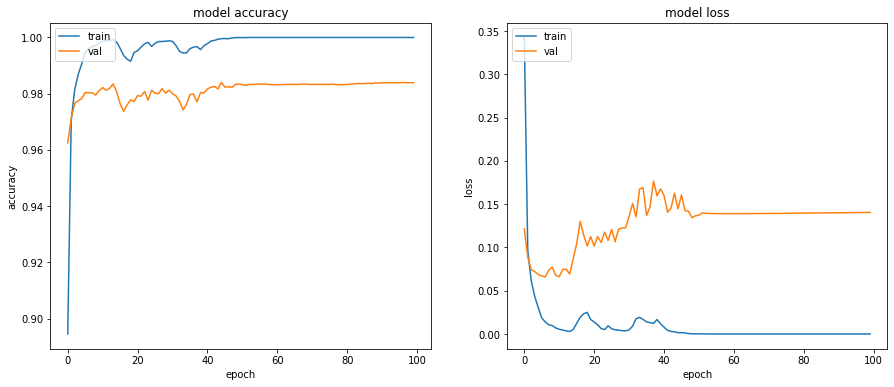

In [ ]:
fig = plt.figure(figsize=(15,6))

ax = fig.add_subplot(1, 2, 1)
ax.plot(train_accuracies)
ax.plot(val_accuracies)
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

ax = fig.add_subplot(1, 2, 2)
ax.plot(train_losses)
ax.plot(val_losses)
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

_=plt.show()

Vemos que alrededor de la época 10 llegamos a un plateau de loss en el validation set, que se empieza a empeorar mas allá de la época 16 (overfitting).

In [ ]:
# limpieza de modelos precedentes
reset_seed()

epocas=14
hidden_1 = 693
batch_size = 986
learning_rate = 0.0088

# Data loader con el batch size de entrenamiento modificado
train_loader = torch.utils.data.DataLoader(dataset_train_descargado, batch_size=batch_size, shuffle=True, num_workers=2)

# Ciclo de entrenamiento
modelo, train_losses, train_accuracies, val_losses, val_accuracies, tiempo = train_model(
    train_batch_size=batch_size, fc1_n=hidden_1, learning_rate=learning_rate, epocas=epocas, device=DEVICE, verbose=True)

train_loss, train_acc = train_losses[epocas-1], train_accuracies[epocas-1]
val_loss, val_acc = val_losses[epocas-1], val_accuracies[epocas-1]

0:  loss: 0.342680, accuracy: 0.894517, val loss: 0.121526, val accuracy: 0.962500 -- epoch time: 5.54
1:  loss: 0.096114, accuracy: 0.970600, val loss: 0.088589, val accuracy: 0.971200 -- epoch time: 5.43
2:  loss: 0.061243, accuracy: 0.981450, val loss: 0.074189, val accuracy: 0.976600 -- epoch time: 5.50
3:  loss: 0.043196, accuracy: 0.986917, val loss: 0.072103, val accuracy: 0.977500 -- epoch time: 5.48
4:  loss: 0.030530, accuracy: 0.990567, val loss: 0.068667, val accuracy: 0.978300 -- epoch time: 5.51
5:  loss: 0.018529, accuracy: 0.994667, val loss: 0.067048, val accuracy: 0.980400 -- epoch time: 5.51
6:  loss: 0.013948, accuracy: 0.996100, val loss: 0.065924, val accuracy: 0.980300 -- epoch time: 5.45
7:  loss: 0.010627, accuracy: 0.996733, val loss: 0.073623, val accuracy: 0.980300 -- epoch time: 5.46
8:  loss: 0.009754, accuracy: 0.997083, val loss: 0.077428, val accuracy: 0.979500 -- epoch time: 5.52
9:  loss: 0.006976, accuracy: 0.998167, val loss: 0.067644, val accuracy: